In [12]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

Working with the following dataset:

https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

In [13]:
df = pd.read_csv(
    "sample_superstore.csv",
    encoding="cp1252",
    dtype={"Postal Code": "string"},
    parse_dates=["Order Date", "Ship Date"],
    date_format="%m/%d/%Y",
)
df["Postal Code"] = df["Postal Code"].str.zfill(5)

print(f"Shape of the DataFrame (rows, columns): {df.shape}")
print(f"First 12 rows of the DataFrame -->")
df.head(12)


Shape of the DataFrame (rows, columns): (9994, 21)
First 12 rows of the DataFrame -->


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   string        
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [15]:
print(f"Missing values in each column:\n{df.isnull().sum()}")

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [16]:
column_profile = pd.DataFrame(
    {
        "imported dtype": df.dtypes.astype(str),
        "non-null count": df.notna().sum(),
        "distinct values": df.nunique(),
    }
)
column_profile


,imported dtype,non-null count,distinct values
Row ID,int64,9994,9994
Order ID,str,9994,5009
Order Date,datetime64[us],9994,1237
Ship Date,datetime64[us],9994,1334
Ship Mode,str,9994,4
Customer ID,str,9994,793
Customer Name,str,9994,793
Segment,str,9994,3
Country,str,9994,1
City,str,9994,531


#### Identify and adjust the variable types

- **Numerical** (`Sales`, `Quantity`, `Discount`, `Profit`): magnitudes where arithmetic is
  valid. `Discount` shows only 12 distinct values but is still a numeric magnitude, not a
  label.
- **Nominal categorical** (`Row ID`, `Order ID`, `Customer ID`, `Customer Name`, `Segment`,
  `Country`, `City`, `State`, `Postal Code`, `Region`, `Product ID`, `Category`,
  `Sub-Category`, `Product Name`): unordered labels. `Row ID` and `Postal Code` look numeric
  but are codes with no valid arithmetic, and textual identifiers remain analytically
  relevant for grouping even at high cardinality.
- **Ordinal categorical** (`Ship Mode`): service levels ordered from slower/cheaper to
  faster: `Standard Class < Second Class < First Class < Same Day`.
- **Temporal** (`Order Date`, `Ship Date`): already parsed as datetimes during import, so
  they need no further conversion.


In [17]:
_superstore_numerical = ["Sales", "Quantity", "Discount", "Profit"]

_superstore_cat_nom = [
    "Row ID", "Order ID", "Customer ID", "Customer Name", "Segment",
    "Country", "City", "State", "Postal Code", "Region", "Product ID",
    "Category", "Sub-Category", "Product Name",
]

_superstore_cat_ord = {
    "Ship Mode": CategoricalDtype(
        categories=["Standard Class", "Second Class", "First Class", "Same Day"],
        ordered=True,
    ),
}

superstore_time = ["Order Date", "Ship Date"]

dtype_map = {col: "float64" for col in _superstore_numerical}
dtype_map.update({col: "category" for col in _superstore_cat_nom})
dtype_map.update(_superstore_cat_ord)

df = df.astype(dtype_map)

_dtype_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "ordered": [
        dtype.ordered if isinstance(dtype, pd.CategoricalDtype) else None
        for dtype in df.dtypes
    ],
})

print(_dtype_info)

                        dtype ordered
Row ID               category   False
Order ID             category   False
Order Date     datetime64[us]    None
Ship Date      datetime64[us]    None
Ship Mode            category    True
Customer ID          category   False
Customer Name        category   False
Segment              category   False
Country              category   False
City                 category   False
State                category   False
Postal Code          category   False
Region               category   False
Product ID           category   False
Category             category   False
Sub-Category         category   False
Product Name         category   False
Sales                 float64    None
Quantity              float64    None
Discount              float64    None
Profit                float64    None


In [18]:
numerical_columns = ["Sales", "Quantity", "Discount", "Profit"]

summary_table = pd.DataFrame(
    {
        "Mean": df[numerical_columns].mean(),
        "Median": df[numerical_columns].median(),
        "Mode": df[numerical_columns].mode().iloc[0],
        "Min": df[numerical_columns].min(),
        "Max": df[numerical_columns].max(),
    }
)

summary_table

,Mean,Median,Mode,Min,Max
Sales,229.858001,54.4900,12.96,0.444,22638.480
Quantity,3.789574,3.0000,3.00,1.000,14.000
Discount,0.156203,0.2000,0.00,0.000,0.800
Profit,28.656896,8.6665,0.00,-6599.978,8399.976


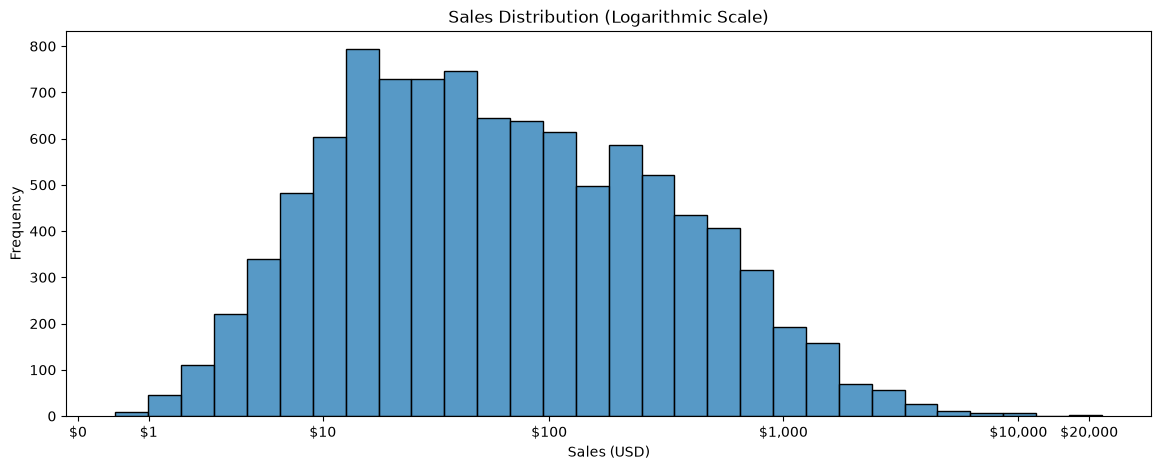

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))  # width, height in inches

sns.histplot(np.log1p(df["Sales"]), bins=30, ax=ax)

sales_ticks = np.array([0, 1, 10, 100, 1_000, 10_000, 20_000])
ax.set_xticks(np.log1p(sales_ticks), [f"${tick:,.0f}" for tick in sales_ticks])
ax.set_title("Sales Distribution (Logarithmic Scale)")
ax.set_xlabel("Sales (USD)")
ax.set_ylabel("Frequency");

Plotted observations: {'Quantity': 9994, 'Discount': 9994}


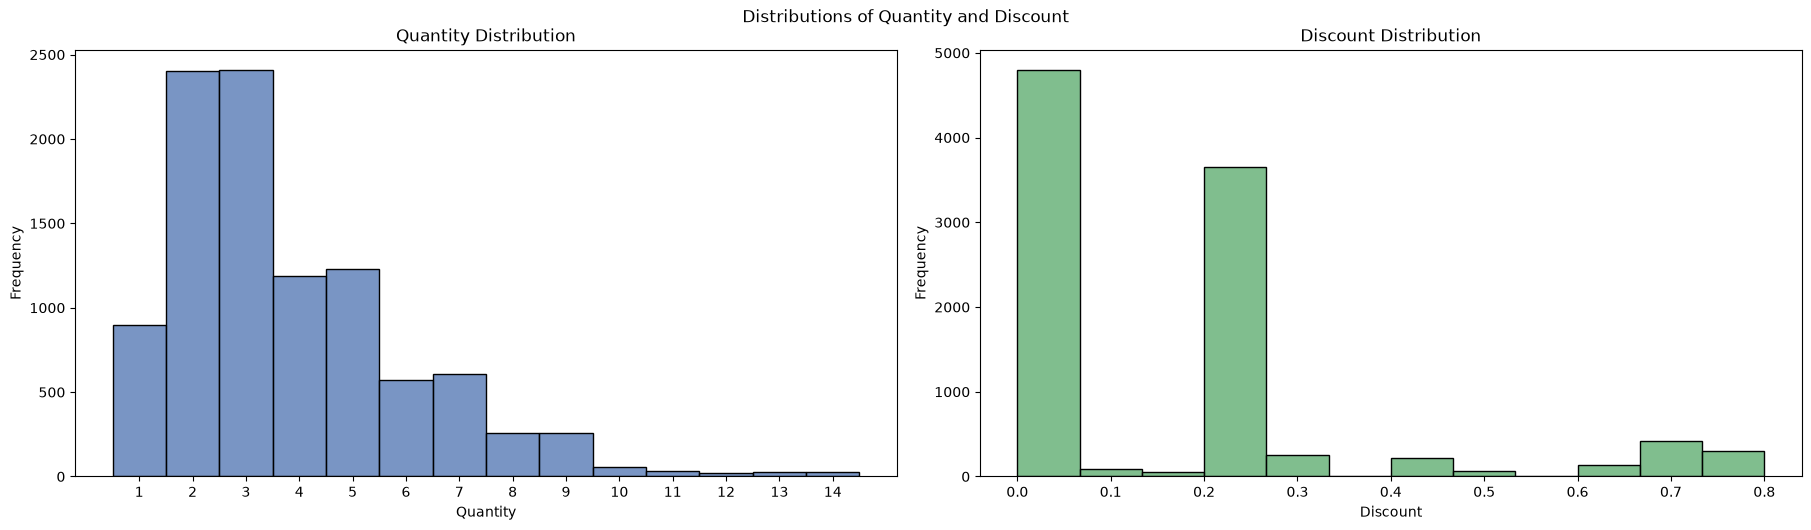

In [20]:
histogram_columns = ["Quantity", "Discount"]
histogram_options = {
    "Quantity": {
        "bins": np.arange(df["Quantity"].min() - 0.5, df["Quantity"].max() + 1.5),
        "color": "#4C72B0",
    },
    "Discount": {"bins": 12, "color": "#55A868"},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
for ax, column in zip(axes, histogram_columns):
    sns.histplot(data=df, x=column, ax=ax, **histogram_options[column])
    ax.set(title=f"{column} Distribution", xlabel=column, ylabel="Frequency")

axes[0].set_xticks(np.arange(df["Quantity"].min(), df["Quantity"].max() + 1))
fig.suptitle("Distributions of Quantity and Discount", y=1.03)
print("Plotted observations:", df[histogram_columns].notna().sum().to_dict())
plt.show()